In [4]:
# Insurance Purchase Predictive Modeling Analysis 
# Phase 1: Data Exploration & Preprocessing
# Phase 2: Descriptive Analytics
# Phase 3: Predictive Modeling

In [60]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                              classification_report, accuracy_score)
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

In [61]:
# Style
PALETTE = ['#FFB6C1', '#9B59B6', '#C39BD3', '#FF69B4', '#6C3483']
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'
OUT = './'

In [62]:
# PHASE 1 - Data Exploration & Preprocessing
print("=" * 60)
print("PHASE 1: DATA EXPLORATION & PREPROCESSING")
print("=" * 60)
 
df = pd.read_excel('D:\Insurance Purchase-1 (1).xlsx',
                   sheet_name='Data')

print(f"\nDataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nTarget Distribution (Ins):")
vc = df['Ins'].value_counts()
print(vc)
print(f"  → {vc[1]/len(df)*100:.1f}% purchased insurance  |  {vc[0]/len(df)*100:.1f}% did not")

PHASE 1: DATA EXPLORATION & PREPROCESSING

Dataset shape: 32,264 rows × 48 columns

Target Distribution (Ins):
Ins
0    21089
1    11175
Name: count, dtype: int64
  → 34.6% purchased insurance  |  65.4% did not


In [63]:
# Missing Values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"\nMissing Values ({len(missing)} columns affected):")
for col, n in missing.items():
    print(f"  {col:<12}: {n:>5} ({n/len(df)*100:.1f}%)")


Missing Values (15 columns affected):
  Age         :  6357 (19.7%)
  Income      :  5782 (17.9%)
  LORes       :  5782 (17.9%)
  HMVal       :  5782 (17.9%)
  HMOwn       :  5533 (17.1%)
  Phone       :  4133 (12.8%)
  POS         :  4133 (12.8%)
  POSAmt      :  4133 (12.8%)
  CC          :  4133 (12.8%)
  CCBal       :  4133 (12.8%)
  CCPurc      :  4133 (12.8%)
  Inv         :  4133 (12.8%)
  InvBal      :  4133 (12.8%)
  AcctAge     :  2070 (6.4%)
  CRScore     :   707 (2.2%)


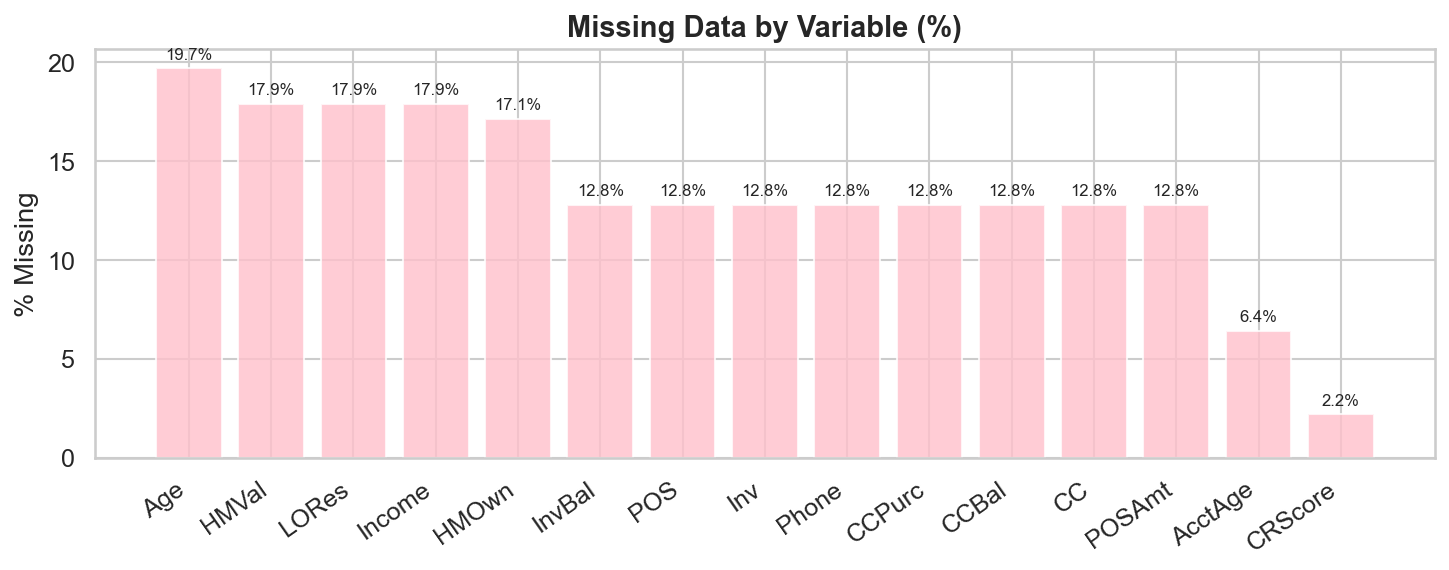

In [82]:
# Figure 1: Missing Data Heatmap
fig, ax = plt.subplots(figsize=(10, 4))
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
bars = ax.bar(missing_pct.index, missing_pct.values, color='pink', alpha=0.8, edgecolor='white')
ax.set_title('Missing Data by Variable (%)', fontweight='bold', fontsize=14)
ax.set_ylabel('% Missing')
ax.set_xlabel('')
plt.xticks(rotation=35, ha='right')
for bar, val in zip(bars, missing_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

In [44]:
# Preprocessing
# Encode categorical columns
le = LabelEncoder()
df['Res_enc'] = le.fit_transform(df['Res'].astype(str))
df['Branch_enc'] = le.fit_transform(df['Branch'].astype(str))
 
# Separate features and target
DROP_COLS = ['Ins', 'Res', 'Branch']
X_raw = df.drop(columns=DROP_COLS)
y = df['Ins']
 
# Impute numeric columns with median
num_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X_raw[num_cols]),
                         columns=num_cols)
 
print(f"\nAfter imputation: {X_imputed.isnull().sum().sum()} missing values remain")

# Summary statistics
print("\nKey Numeric Variable Statistics (post-imputation):")
key_vars = ['Age', 'Income', 'HMVal', 'CRScore', 'DDABal', 'SavBal']
print(X_imputed[key_vars].describe().round(2))


After imputation: 0 missing values remain

Key Numeric Variable Statistics (post-imputation):
            Age    Income     HMVal   CRScore     DDABal     SavBal
count  32264.00  32264.00  32264.00  32264.00   32264.00   32264.00
mean      47.94     39.59    110.21    666.50    2170.02    3170.60
std       12.64     25.92     19.94     39.97    7282.73   13397.15
min       16.00      0.00     67.00    509.00    -774.83       0.00
25%       40.00     23.00    100.00    640.00      59.94       0.00
50%       48.00     35.00    107.00    667.00     571.82       0.00
75%       55.00     49.00    117.00    693.00    1834.23    1215.82
max       94.00    233.00    754.00    820.00  278093.83  700026.94


In [66]:
# PHASE 2 - Descriptive Anlaytics
print("\n" + "=" * 60)
print("PHASE 2: DESCRIPTIVE ANALYTICS")
print("=" * 60)
 
df_plot = X_imputed.copy()
df_plot['Ins'] = y.values
df_plot['Res'] = df['Res'].values
df_plot['Branch'] = df['Branch'].values


PHASE 2: DESCRIPTIVE ANALYTICS


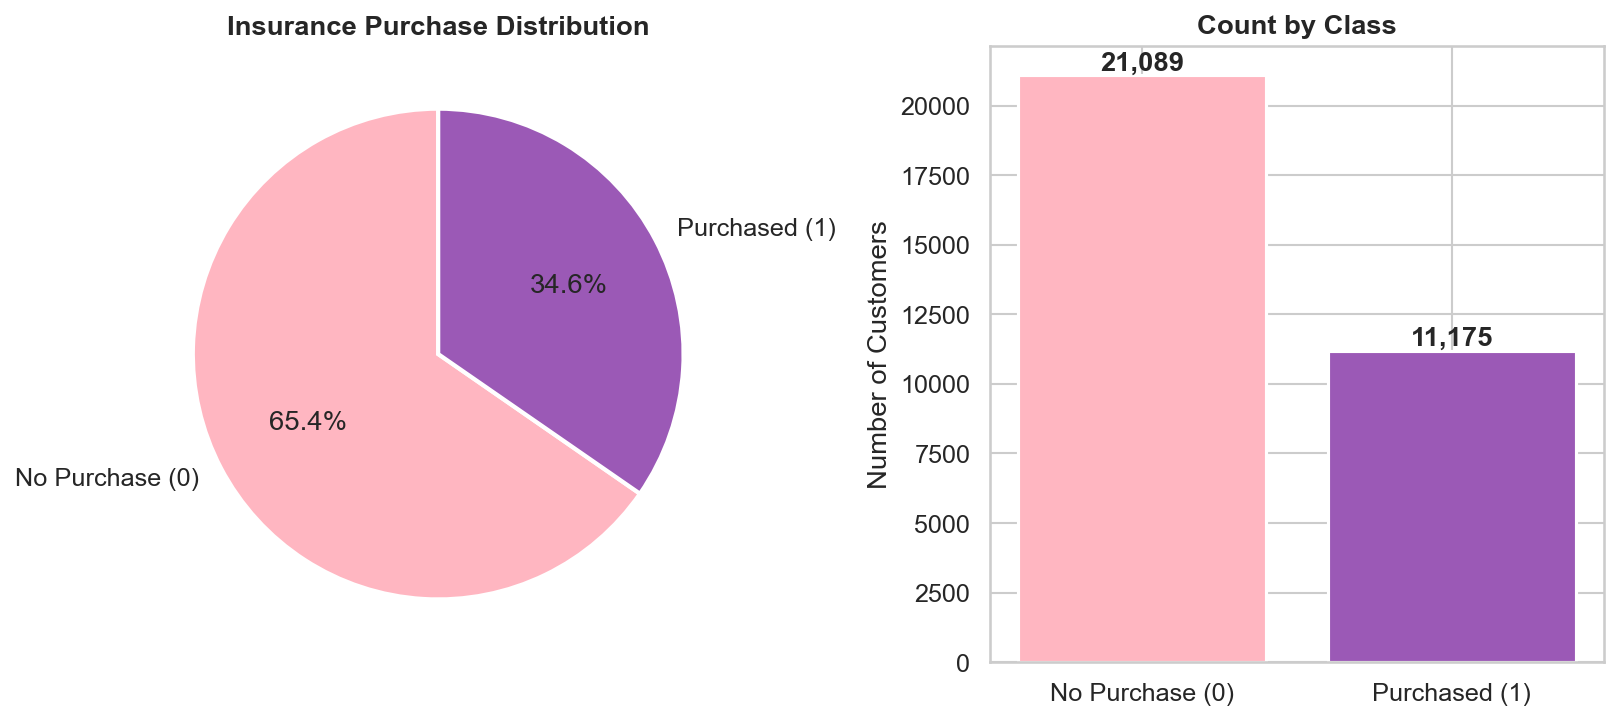

In [89]:
# Figure 2: Target Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
labels = ['No Purchase (0)', 'Purchased (1)']
sizes  = [vc[0], vc[1]]
colors = ['#FFB6C1', '#9B59B6']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Insurance Purchase Distribution', fontweight='bold')
 
axes[1].bar(labels, sizes, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Count by Class', fontweight='bold')
axes[1].set_ylabel('Number of Customers')
for i, v in enumerate(sizes):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

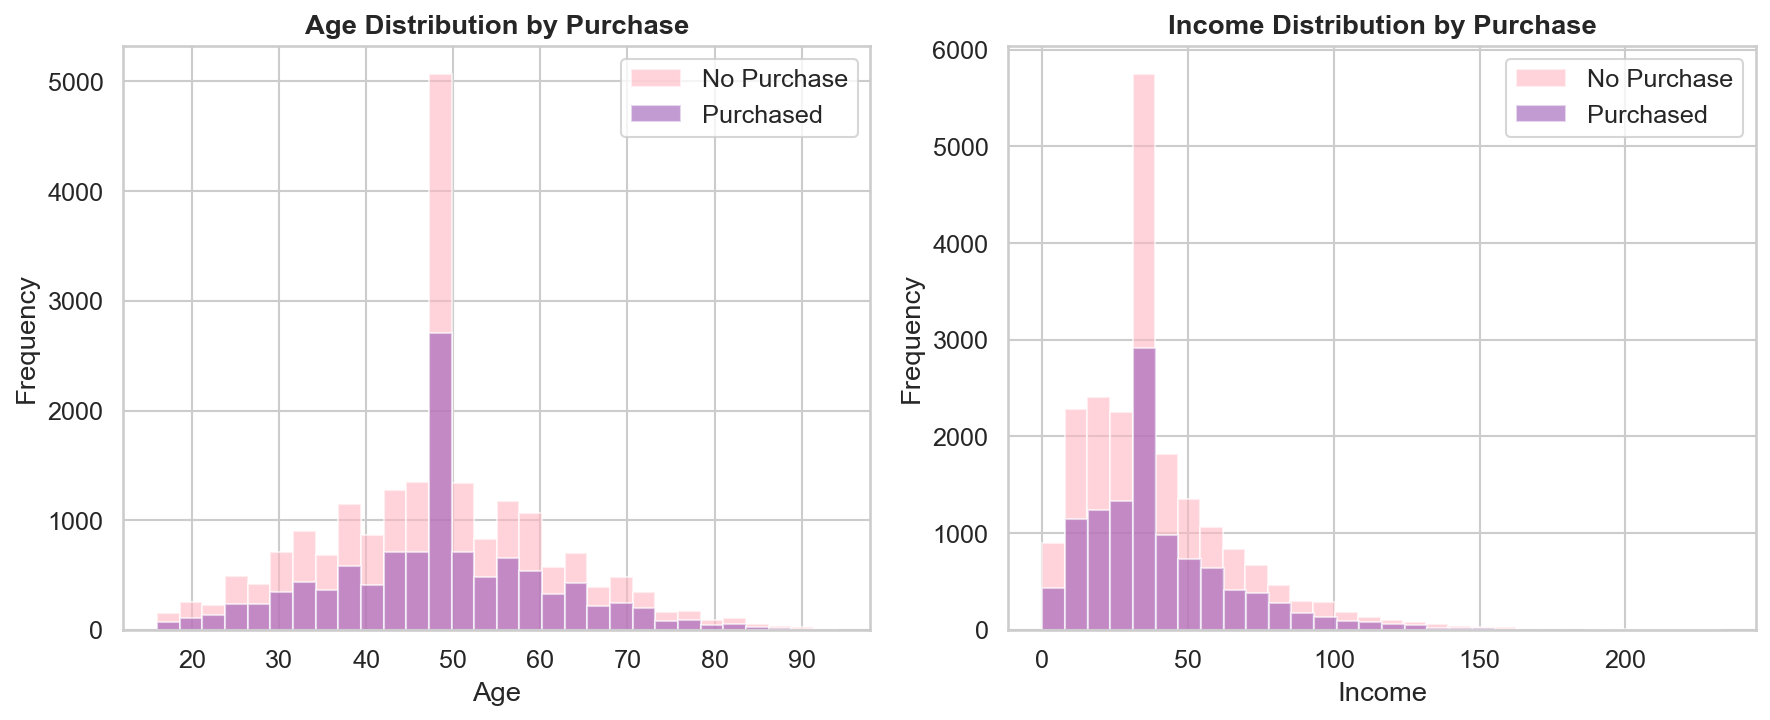

In [90]:
# Figure 3: Age & Income Distributions by Purchase
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, title in zip(axes, ['Age', 'Income'],
                           ['Age Distribution by Purchase', 'Income Distribution by Purchase']):
    for val, lbl, col_c in zip([0, 1], ['No Purchase', 'Purchased'], ['#FFB6C1', '#9B59B6']):
        subset = df_plot[df_plot['Ins'] == val][col].dropna()
        ax.hist(subset, bins=30, alpha=0.6, label=lbl, color=col_c, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()
plt.tight_layout()
plt.show()


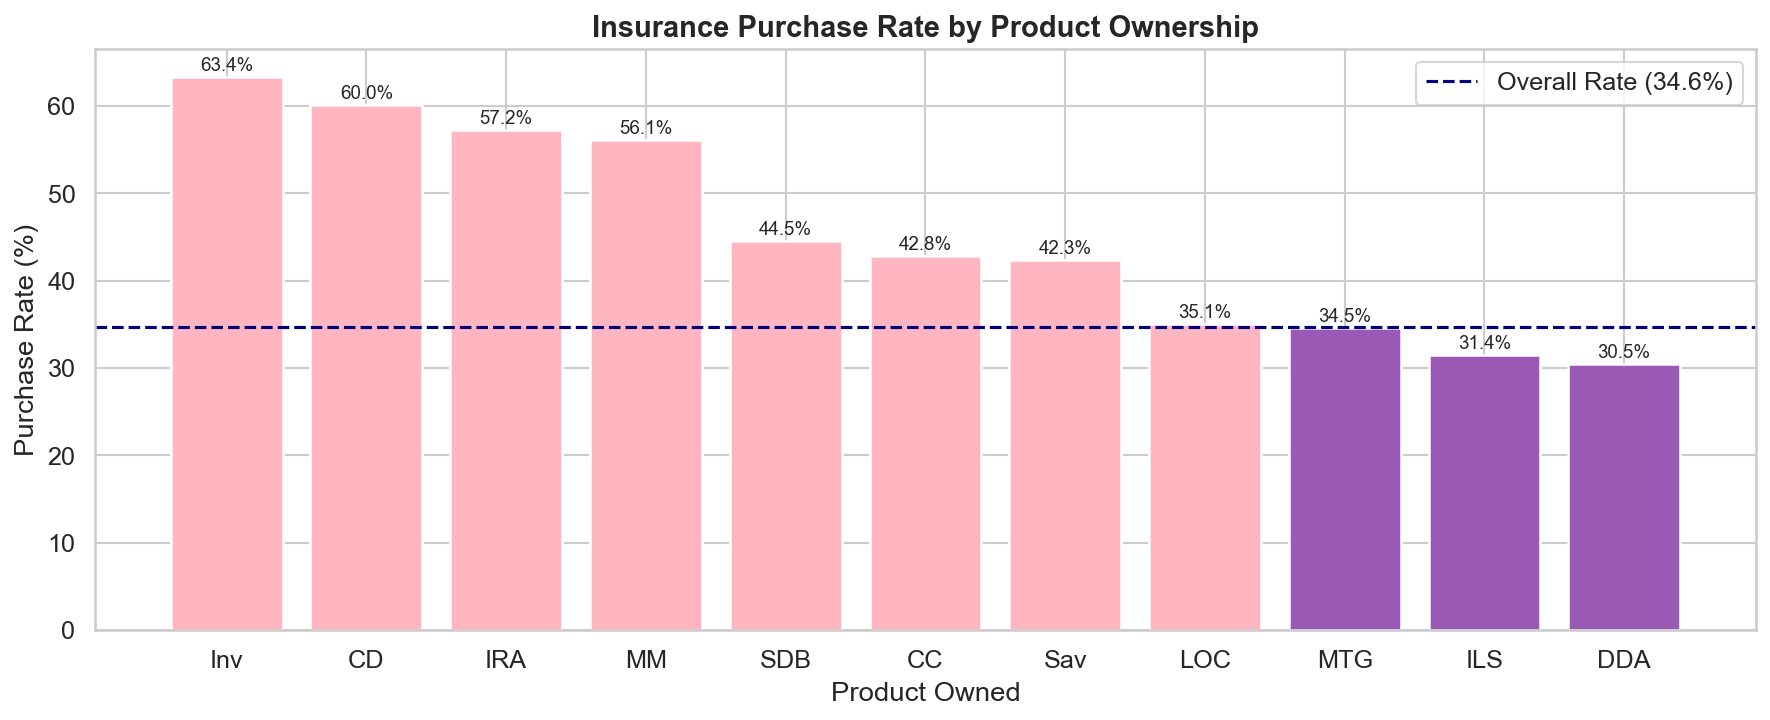

In [93]:
# Figure 4: Account Product Ownership vs Purchase Rate
product_cols = ['DDA','Sav','CD','IRA','MM','MTG','CC','Inv','LOC','ILS','SDB']
purchase_rates = {col: df_plot[df_plot[col]==1]['Ins'].mean()*100
                  for col in product_cols if col in df_plot.columns}
base_rate = df_plot['Ins'].mean() * 100
 
fig, ax = plt.subplots(figsize=(12, 5))
sorted_items = sorted(purchase_rates.items(), key=lambda x: x[1], reverse=True)
cols_sorted, rates_sorted = zip(*sorted_items)
bar_colors = ['#FFB6C1' if r > base_rate else '#9B59B6' for r in rates_sorted]
bars = ax.bar(cols_sorted, rates_sorted, color=bar_colors, edgecolor='white', linewidth=1.2)
ax.axhline(base_rate, color='navy', linestyle='--', linewidth=1.5, label=f'Overall Rate ({base_rate:.1f}%)')
ax.set_title('Insurance Purchase Rate by Product Ownership', fontweight='bold', fontsize=14)
ax.set_ylabel('Purchase Rate (%)')
ax.set_xlabel('Product Owned')
ax.legend()
for bar, val in zip(bars, rates_sorted):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

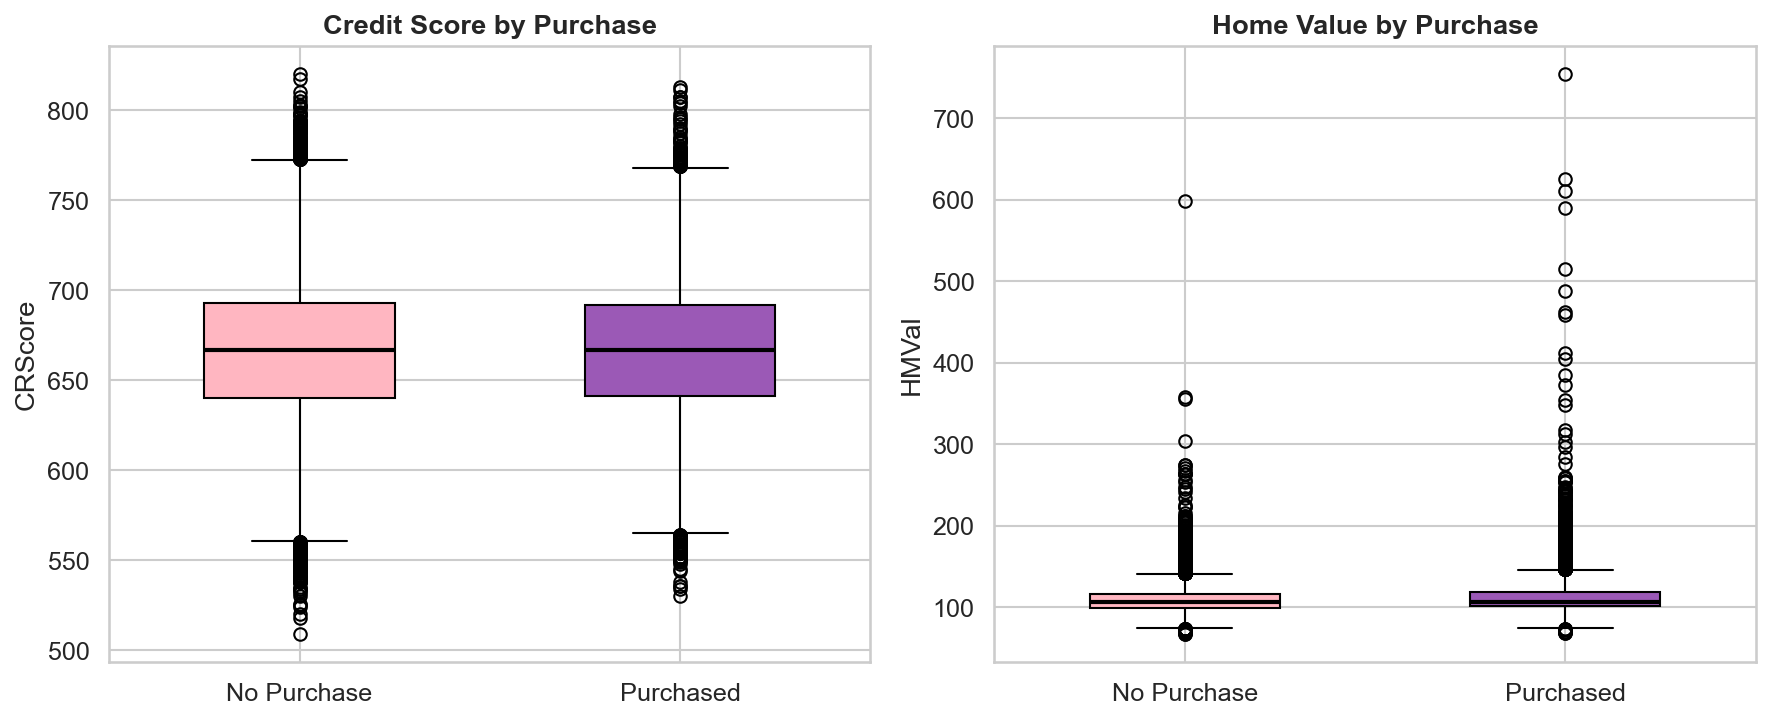

In [94]:
# Figure 5: CRScore & HMVal Box Plots by Purchase
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, title in zip(axes,
                            ['CRScore', 'HMVal'],
                            ['Credit Score by Purchase', 'Home Value by Purchase']):
    data = [df_plot[df_plot['Ins']==0][col].dropna(),
            df_plot[df_plot['Ins']==1][col].dropna()]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#FFB6C1')
    bp['boxes'][1].set_facecolor('#9B59B6')
    ax.set_xticklabels(['No Purchase', 'Purchased'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

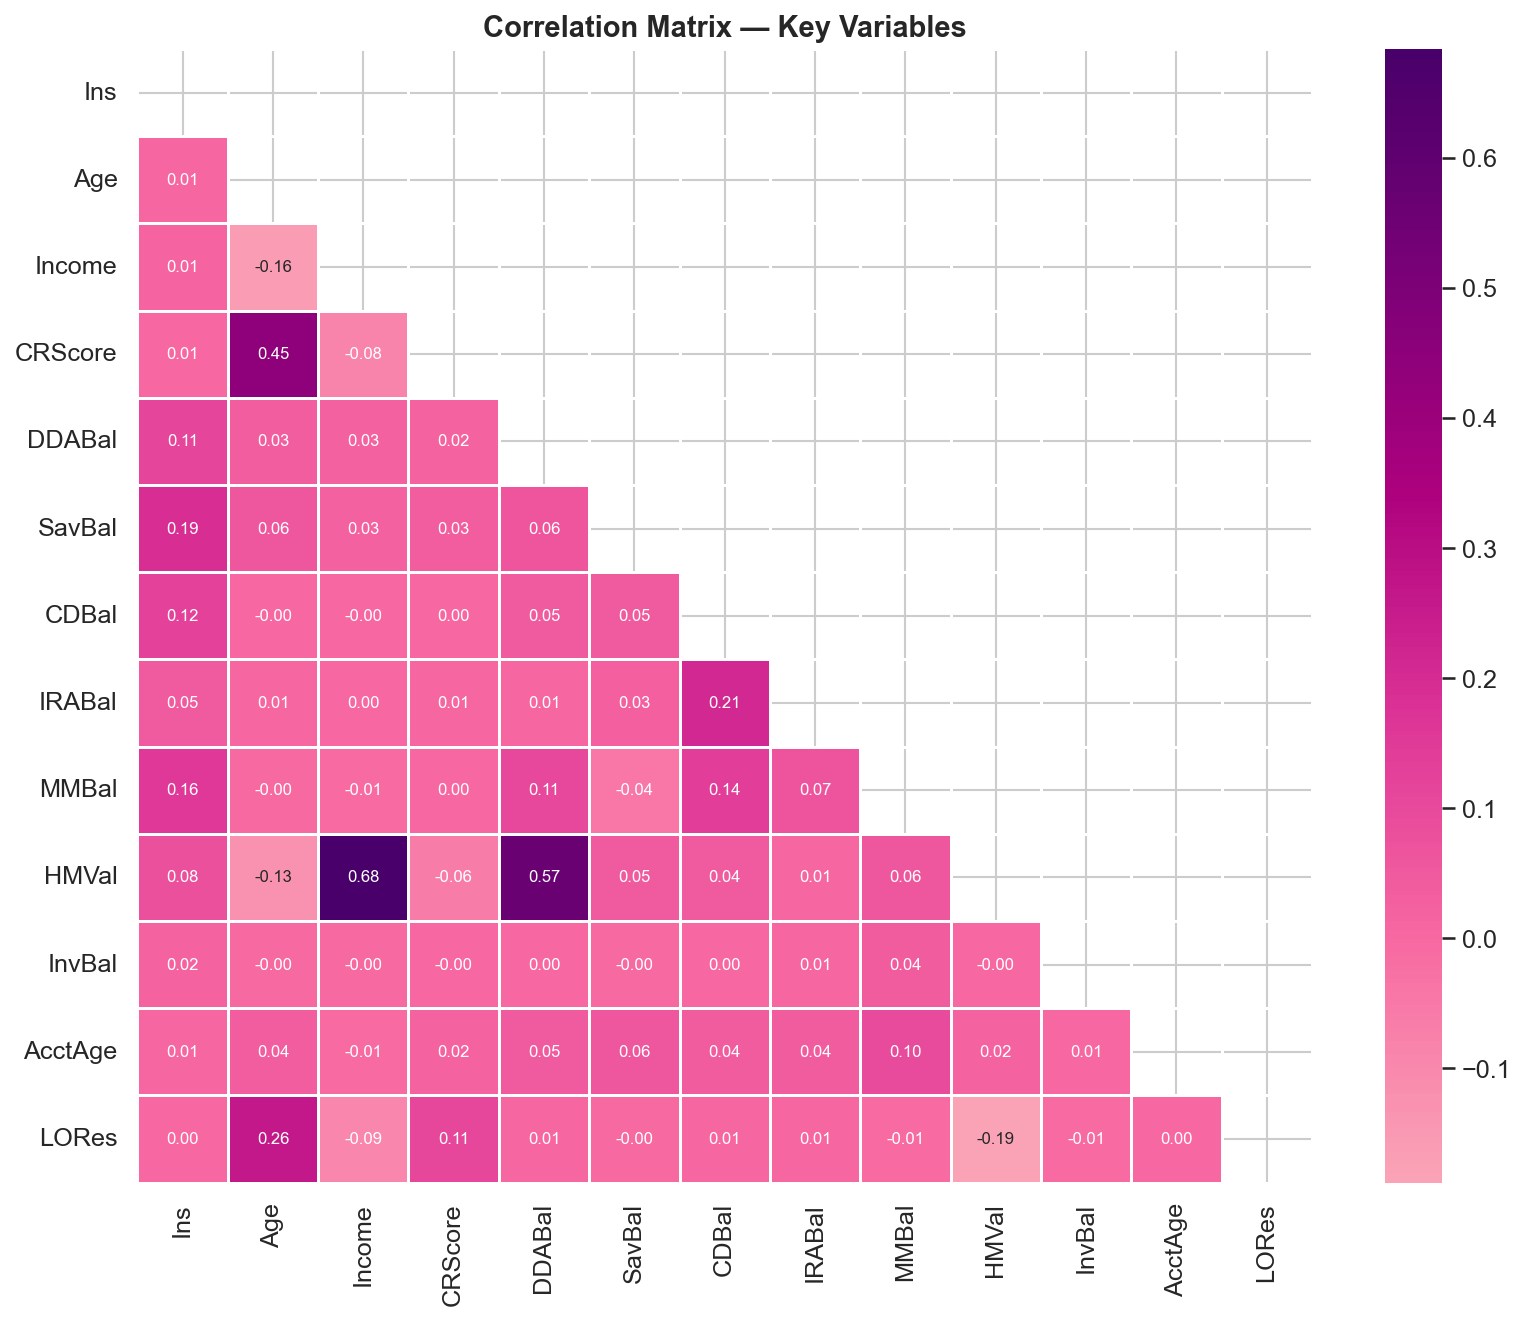

In [97]:
# Figure 6: Correlation Heatmap (top features)
corr_cols = ['Ins','Age','Income','CRScore','DDABal','SavBal','CDBal',
             'IRABal','MMBal','HMVal','InvBal','AcctAge','LORes']
corr_cols = [c for c in corr_cols if c in df_plot.columns]
corr_matrix = df_plot[corr_cols].corr()
 
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdPu',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Key Variables', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

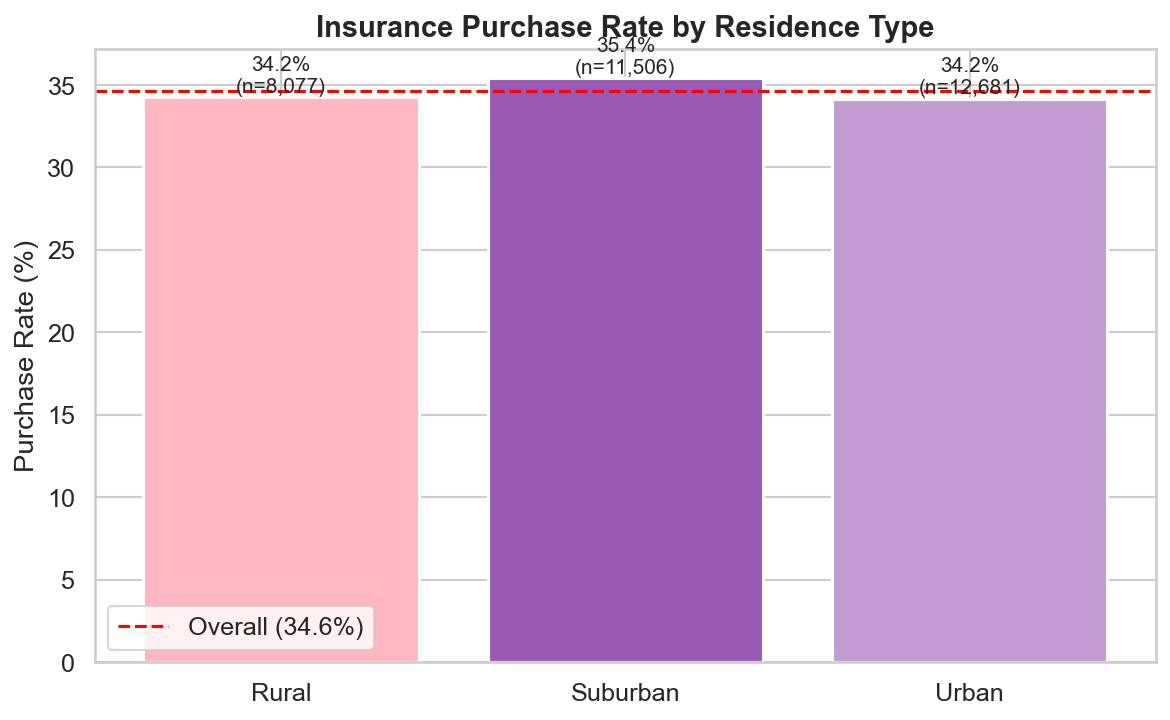


Pivot: Mean Income & CRScore by Ins:
     Income  CRScore    Age   HMVal
Ins                                
0     39.33   666.35  47.84  109.11
1     40.08   666.80  48.13  112.28


In [98]:
# Figure 7: Residence Type vs Purchase Rate
res_group = df_plot.groupby('Res')['Ins'].agg(['mean','count']).reset_index()
res_group['mean'] *= 100
res_labels = {'R': 'Rural', 'S': 'Suburban', 'U': 'Urban'}
res_group['Label'] = res_group['Res'].map(res_labels).fillna(res_group['Res'])
 
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(res_group['Label'], res_group['mean'],
              color=['#FFB6C1', '#9B59B6', '#C39BD3'], edgecolor='white', linewidth=1.5)
ax.axhline(base_rate, color='red', linestyle='--', linewidth=1.5, label=f'Overall ({base_rate:.1f}%)')
ax.set_title('Insurance Purchase Rate by Residence Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Purchase Rate (%)')
ax.legend()
for bar, (_, row) in zip(bars, res_group.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{row['mean']:.1f}%\n(n={row['count']:,})", ha='center', fontsize=10)
plt.tight_layout()
plt.show()
 
# Pivot-table insight
print("\nPivot: Mean Income & CRScore by Ins:")
pivot = df_plot.groupby('Ins')[['Income','CRScore','Age','HMVal']].mean().round(2)
print(pivot)

In [73]:
# PHASE 3 - Predicitive Modeling
print("\n" + "=" * 60)
print("PHASE 3: PREDICTIVE MODELING")
print("=" * 60)
 
# ── Train/Test Split ─────────────────────────────────────────────────────
X = X_imputed.copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
 
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
 
print(f"\nTrain: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")


PHASE 3: PREDICTIVE MODELING

Train: 24,198  |  Test: 8,066


In [74]:
# Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=12,
                                                   random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                                       learning_rate=0.1, random_state=42),
    'Neural Network':      MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300,
                                         random_state=42, early_stopping=True),
}
 
results = {}
for name, model in models.items():
    print(f"\nTraining: {name} ...")
    # Scaled data for LR and NN; unscaled for tree models
    use_scaled = name in ('Logistic Regression', 'Neural Network')
    Xtr = X_train_sc if use_scaled else X_train.values
    Xte = X_test_sc  if use_scaled else X_test.values
    model.fit(Xtr, y_train)
    y_pred      = model.predict(Xte)
    y_prob      = model.predict_proba(Xte)[:, 1]
    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    cm   = confusion_matrix(y_test, y_pred)
    results[name] = dict(model=model, acc=acc, auc=auc,
                         fpr=fpr, tpr=tpr, y_pred=y_pred, y_prob=y_prob, cm=cm,
                         use_scaled=use_scaled)
    print(f"  Accuracy: {acc:.4f}  |  ROC-AUC: {auc:.4f}")


Training: Logistic Regression ...
  Accuracy: 0.7289  |  ROC-AUC: 0.7741

Training: Decision Tree ...
  Accuracy: 0.7368  |  ROC-AUC: 0.7723

Training: Random Forest ...
  Accuracy: 0.7544  |  ROC-AUC: 0.8083

Training: Gradient Boosting ...
  Accuracy: 0.7559  |  ROC-AUC: 0.8120

Training: Neural Network ...
  Accuracy: 0.7434  |  ROC-AUC: 0.7935


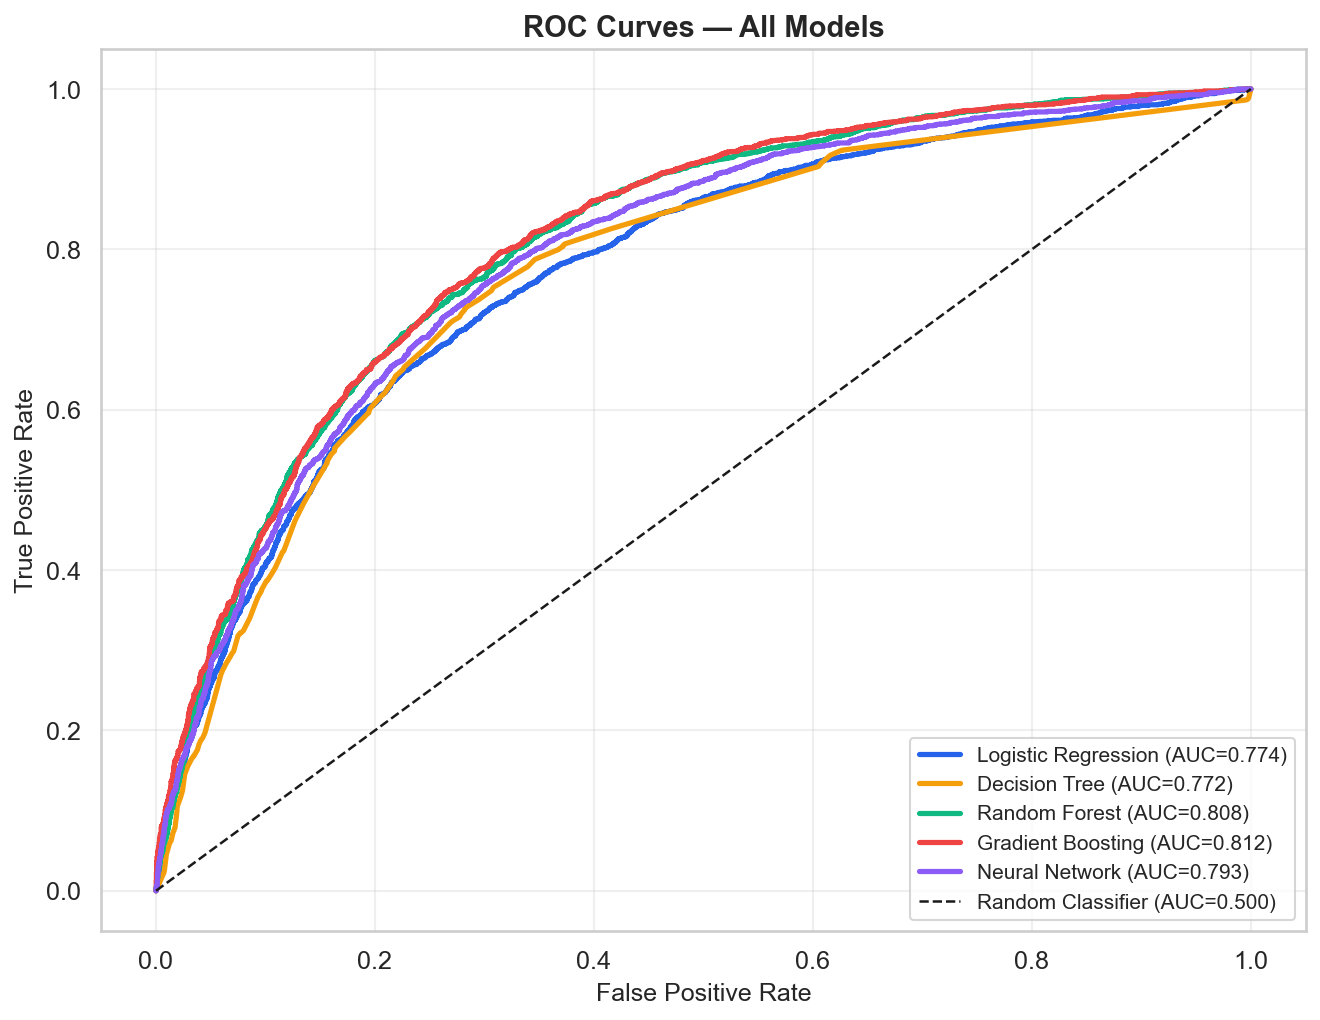

In [76]:
# Figure 8: ROC Curves
fig, ax = plt.subplots(figsize=(9, 7))
for (name, res), color in zip(results.items(), PALETTE):
    ax.plot(res['fpr'], res['tpr'], lw=2.5, color=color,
            label=f"{name} (AUC={res['auc']:.3f})")
ax.plot([0,1],[0,1],'k--', lw=1.2, label='Random Classifier (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontweight='bold', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

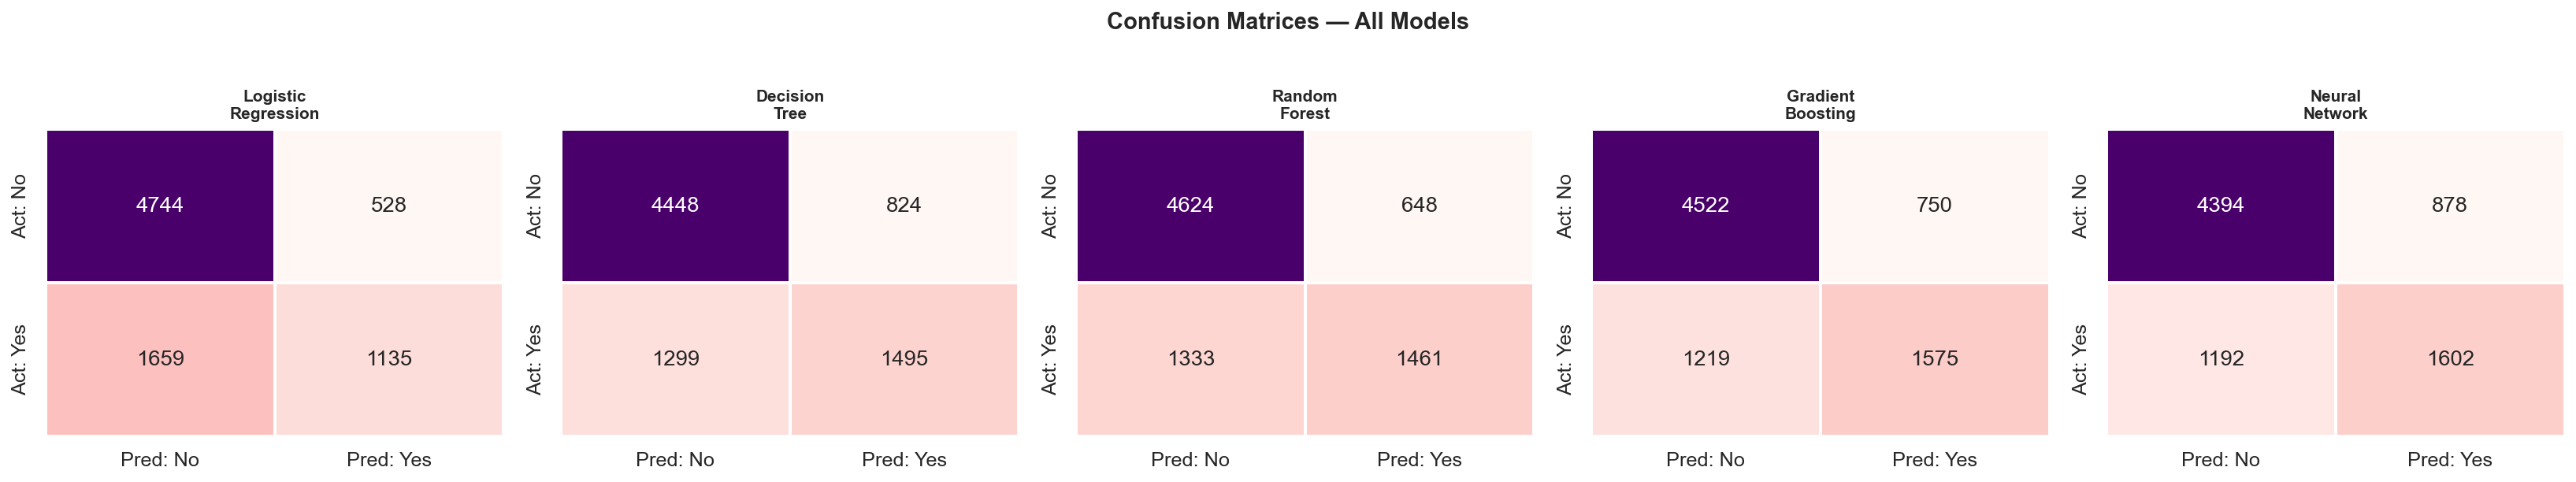

In [99]:
# Figure 9: Confusion Matrices
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, res) in zip(axes, results.items()):
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='RdPu', ax=ax,
                xticklabels=['Pred: No','Pred: Yes'],
                yticklabels=['Act: No','Act: Yes'],
                linewidths=1, cbar=False)
    ax.set_title(name.replace(' ', '\n'), fontweight='bold', fontsize=10)
plt.suptitle('Confusion Matrices — All Models', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

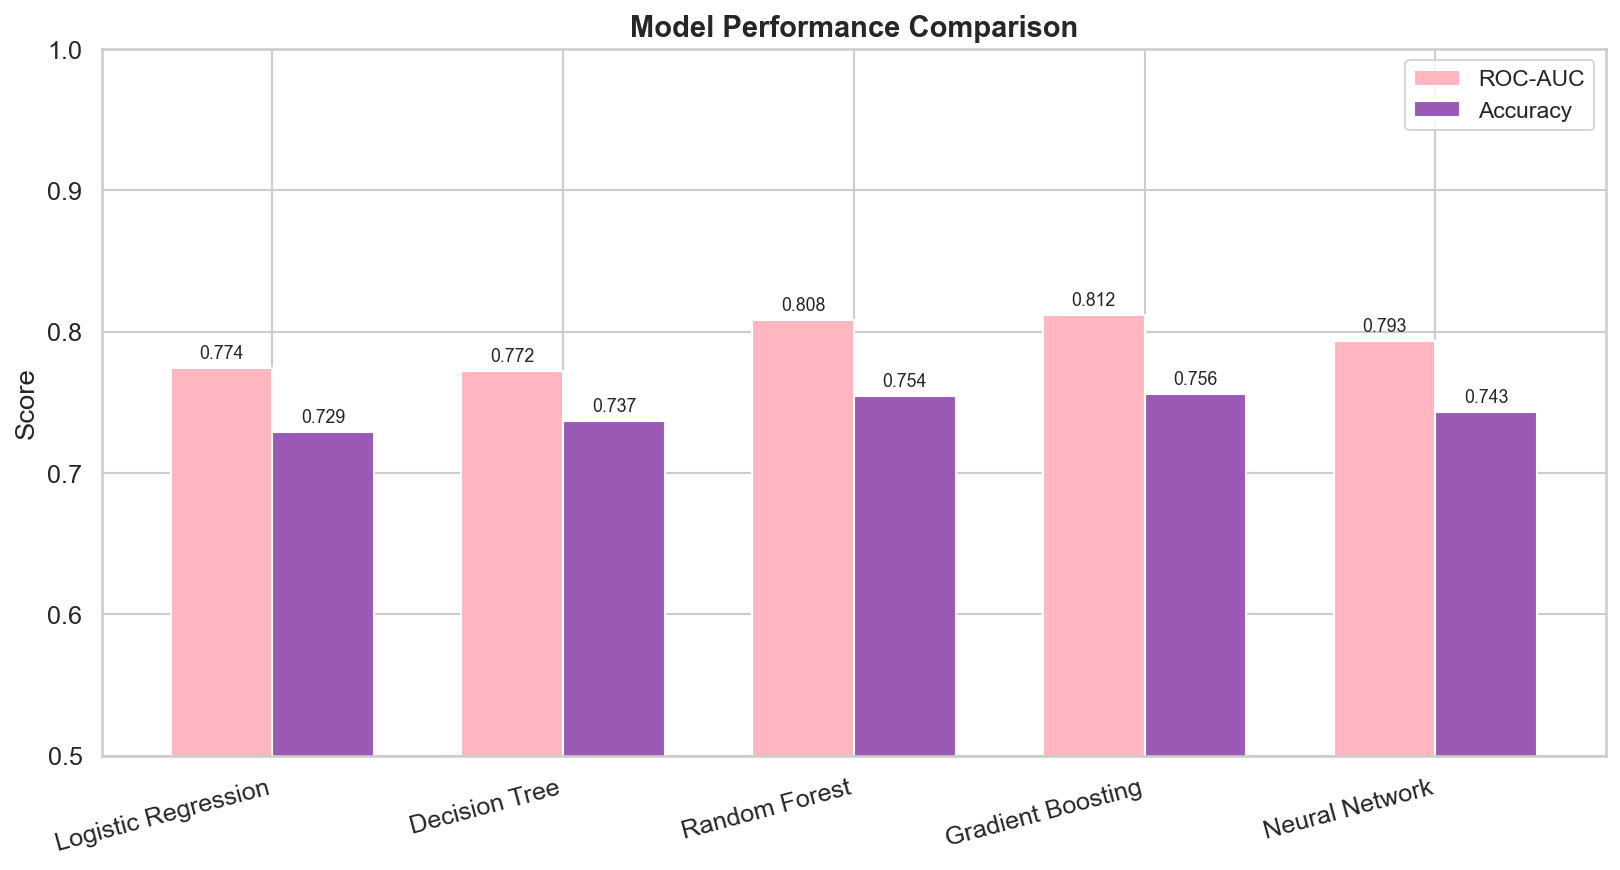

In [100]:
# Figure 10: Model Comparison Bar Chart
names = list(results.keys())
aucs  = [results[n]['auc'] for n in names]
accs  = [results[n]['acc'] for n in names]
 
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(names))
w = 0.35
b1 = ax.bar(x - w/2, aucs, w, label='ROC-AUC', color='#FFB6C1', edgecolor='white')
b2 = ax.bar(x + w/2, accs, w, label='Accuracy', color='#9B59B6', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)
plt.tight_layout()
plt.show()

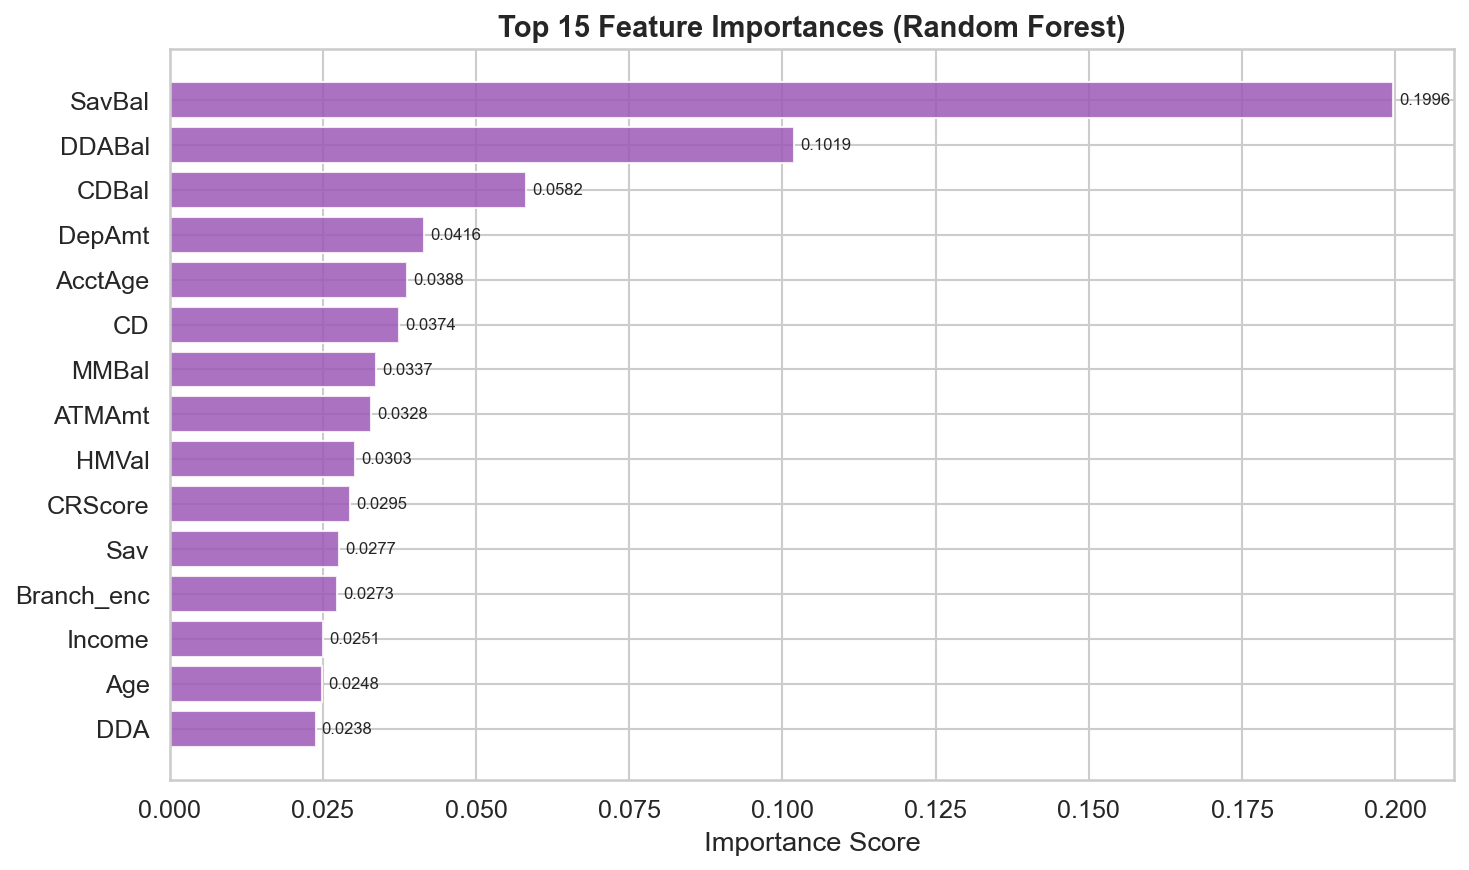

In [101]:
# Feature Importance (Random Forest)
rf_model = results['Random Forest']['model']
fi = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
 
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(fi.index[::-1], fi.values[::-1], color='#9B59B6', alpha=0.85, edgecolor='white')
ax.set_title('Top 15 Feature Importances (Random Forest)', fontweight='bold', fontsize=14)
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, fi.values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

In [102]:
# Summary Table
print("\n" + "=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)
summary = pd.DataFrame({
    'Model': names,
    'Accuracy': [f"{results[n]['acc']:.4f}" for n in names],
    'ROC-AUC':  [f"{results[n]['auc']:.4f}" for n in names],
}).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))
 
best_model = max(results.items(), key=lambda x: x[1]['auc'])
print(f"\n✓ Best Model: {best_model[0]} (AUC = {best_model[1]['auc']:.4f})")
print("\nDetailed Classification Report — Best Model:")
print(classification_report(y_test, best_model[1]['y_pred'],
                             target_names=['No Purchase','Purchased']))


FINAL MODEL SUMMARY
              Model Accuracy ROC-AUC
  Gradient Boosting   0.7559  0.8120
      Random Forest   0.7544  0.8083
     Neural Network   0.7434  0.7935
Logistic Regression   0.7289  0.7741
      Decision Tree   0.7368  0.7723

✓ Best Model: Gradient Boosting (AUC = 0.8120)

Detailed Classification Report — Best Model:
              precision    recall  f1-score   support

 No Purchase       0.79      0.86      0.82      5272
   Purchased       0.68      0.56      0.62      2794

    accuracy                           0.76      8066
   macro avg       0.73      0.71      0.72      8066
weighted avg       0.75      0.76      0.75      8066

